# LangChain Core Concepts: The Complete Mastery Guide

## 1. MODELS & THEIR TYPES

- Models are the AI engines that power our LLM applications, using langchain's "Model" we can interact with a lot of different open or closed source models very easily
- we can re-use the same code everytime for all different models OpenAI, Anthropic, Google, HuggingFace, etc

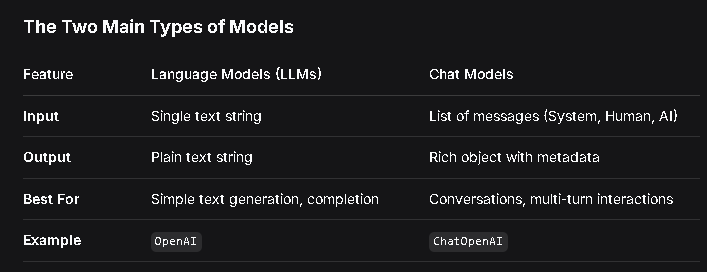

### Why Use LangChain's Model Abstraction?

#### 1. Provider Agnostic: Swap models with one line change

In [1]:
# From OpenAI
from langchain_openai import ChatOpenAI
model = ChatOpenAI(model="gpt-4o-mini")

# To Anthropic (same interface!)
from langchain_anthropic import ChatAnthropic
model = ChatAnthropic(model="claude-3-sonnet-20240229")

d:\Agentic AI\GenAI using Langchain\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### 2. Standardized Interface: All models support these methods:

In [2]:
# .invoke() - Single request

# .stream() - Streaming responses

# .batch() - Multiple requests

#### 3. Built-in Features: Token counting, rate limiting, retry logic

### Key params to tune in models

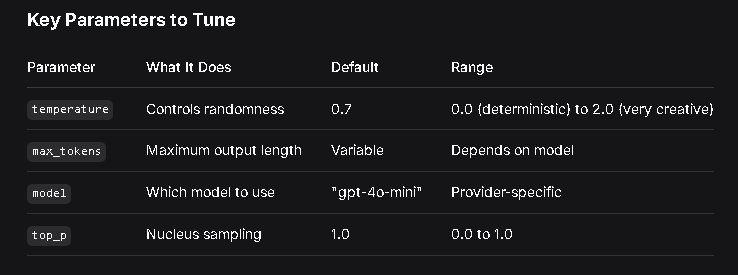

### Code Examples

In [3]:
from langchain_openai import ChatOpenAI
from langchain_anthropic import ChatAnthropic
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv;load_dotenv()

True

In [4]:
# --- OpenAI ---
openai_model = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0.7,
    max_tokens=25
)

response = openai_model.invoke("What is LangChain?")
print(response.content)
print(f"Tokens used: {response.usage_metadata}")

LangChain is a framework designed for developing applications that utilize large language models (LLMs). It provides tools and components that simplify
Tokens used: {'input_tokens': 12, 'output_tokens': 25, 'total_tokens': 37, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}


In [5]:
# # --- Anthropic (Claude) ---
# claude_model = ChatAnthropic(
#     model="claude-3-sonnet-20240229",
#     temperature=0.5
# )
# response = claude_model.invoke("Explain Python in one sentence.")
# print(response.content)

# # --- Google Gemini ---
# gemini_model = ChatGoogleGenerativeAI(
#     model="gemini-pro",
#     temperature=0.3
# )
# response = gemini_model.invoke("What is machine learning?")
# print(response.content)

### Temprature

In [6]:
# Temperature 0 = Always the same output
model_deterministic = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0,
    max_tokens=50
)

# Temperature 1 = Maximum creativity
model_creative = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=1.0,
    max_tokens=50
)

# prompt = "Write a creative slogan for a coffee shop."

# print("Temperature 0 (Deterministic):")
# print(model_deterministic.invoke(prompt).content)

# print("\nTemperature 1 (Creative):")
# print(model_creative.invoke(prompt).content)

###  Embedding Models

In [7]:
# from langchain_openai import OpenAIEmbeddings

# # --- Basic embedding ---
# embedding = OpenAIEmbeddings(
#     model="text-embedding-3-small",
#     dimensions=32  # Reduce dimensions for faster processing
# )

# # Single text to vector
# vector = embedding.embed_query("Paris is the capital of France")
# print(f"Vector length: {len(vector)}")
# print(f"First 10 values: {vector[:10]}")

# # Multiple texts to vectors
# texts = [
#     "Machine learning is a subset of AI.",
#     "Deep learning uses neural networks.",
#     "Python is a programming language."
# ]
# vectors = embedding.embed_documents(texts)
# print(f"Generated {len(vectors)} vectors")

# # --- Similarity search ---
# query = "What is AI?"
# query_vector = embedding.embed_query(query)

# # Calculate similarity (cosine similarity)
# import numpy as np
# from sklearn.metrics.pairwise import cosine_similarity

# query_vec = np.array(query_vector).reshape(1, -1)
# vectors_array = np.array(vectors)

# similarities = cosine_similarity(query_vec, vectors_array)[0]
# for i, sim in enumerate(similarities):
#     print(f"Similarity to '{texts[i]}': {sim:.4f}")

## 2. PROMPTS & TEMPLATES

- Parametric knowledge is everything the model "memorized" during training (facts, logic, patterns) stored within its billions of weights.
- Prompts are the instructions given to LLM to extract that knowledge, tiny change in prompt will change the output

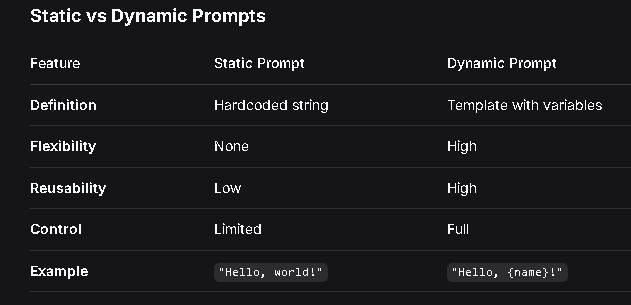

- **Types of Prompt Templates**
1. PromptTemplate - For LLMs (text in, text out)
2. ChatPromptTemplate - For Chat Models (system/human/ai messages)
3. MessagesPlaceholder - For dynamic message lists (chat history)
4. load_prompt - Load from a JSON file

- The Five Components of a Chat Prompt

1. System: Sets behavior
2. Human: User's input
3. AI: Assistant's response (for few-shot examples)
4. Placeholder: For variable content like chat history
5. Format: How to format the final prompt

### Code Examples

#### Basic PromptTemplate

In [8]:
from langchain_core.prompts import PromptTemplate
from langchain_openai import ChatOpenAI

# --- Simple template ---
template = PromptTemplate(
    template="Explain {topic} in {style} language for a {audience} in less then 1 line.",
    input_variables=["topic", "style", "audience"]
)

prompt = template.invoke({
    "topic": "quantum computing",
    "style": "simple",
    "audience": "10-year-old"
})

print(f"Generated prompt:\n{prompt}\n")

model = ChatOpenAI(model="gpt-4o-mini")
response = model.invoke(prompt)
print(f"Response:\n{response.content}")

Generated prompt:
text='Explain quantum computing in simple language for a 10-year-old in less then 1 line.'

Response:
Quantum computing is a super-fast kind of computing that uses tiny particles to solve problems much quicker than regular computers.


#### ChatPromptTemplate (System + Human)

In [9]:
from langchain_core.prompts import ChatPromptTemplate

# --- With system message ---
chat_template = ChatPromptTemplate.from_messages([
    ("system", "You are a {role} expert with {years} years of experience."),
    ("human", "Explain {topic} in simple terms."),
    ("ai", "I'll explain {topic} simply."),  # Optional: few-shot example
    ("human", "Actually, can you make it even simpler in absolutely less then 1 line?")
])

prompt = chat_template.invoke({
    "role": "physics",
    "years": "10",
    "topic": "quantum entanglement"
})

print(f"Messages:\n{prompt}")

Messages:
messages=[SystemMessage(content='You are a physics expert with 10 years of experience.', additional_kwargs={}, response_metadata={}), HumanMessage(content='Explain quantum entanglement in simple terms.', additional_kwargs={}, response_metadata={}), AIMessage(content="I'll explain quantum entanglement simply.", additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='Actually, can you make it even simpler in absolutely less then 1 line?', additional_kwargs={}, response_metadata={})]


#### MessagesPlaceholder (For Memory)

In [10]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.messages import HumanMessage, AIMessage

# --- With chat history placeholder ---
template = ChatPromptTemplate.from_messages([
    ("system", "You are a helpful assistant."),
    MessagesPlaceholder(variable_name="chat_history"),
    ("human", "{user_input}")
])

# Usage with history
chat_history = [
    HumanMessage(content="What is Python?"),
    AIMessage(content="Python is a programming language.")
]

prompt = template.invoke({
    "chat_history": chat_history,
    "user_input": "What is it used for?"
})

print(prompt)

messages=[SystemMessage(content='You are a helpful assistant.', additional_kwargs={}, response_metadata={}), HumanMessage(content='What is Python?', additional_kwargs={}, response_metadata={}), AIMessage(content='Python is a programming language.', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='What is it used for?', additional_kwargs={}, response_metadata={})]


####  Loading Prompts from Files

In [11]:
from langchain_core.prompts import load_prompt

template = load_prompt("template.json")

prompt = template.invoke({
    "paper": "Attention Is All You Need",
    "style": "beginner-friendly"
})

C:\Users\iampr\AppData\Local\Temp\ipykernel_12588\610187477.py:3: LangChainDeprecationWarning: The function `load_prompt` was deprecated in LangChain 1.2.21 and will be removed in 2.0.0. Use `Use `dumpd`/`dumps` from `langchain_core.load` to serialize prompts and `load`/`loads` to deserialize them.` instead.
  template = load_prompt("template.json")
No `_type` key found, defaulting to `prompt`.


In [12]:
prompt

StringPromptValue(text='You are a research paper summarizer.\n\nPaper: Attention Is All You Need\nStyle: beginner-friendly\n\nProvide a summary including:\n1. Main idea\n2. Key contributions\n3. Real-world applications')

## 3. CHAINS

- Chains allow you to sequence operations. The output of one step becomes the input for the next.

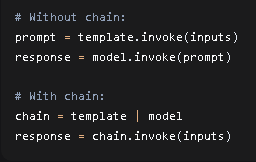

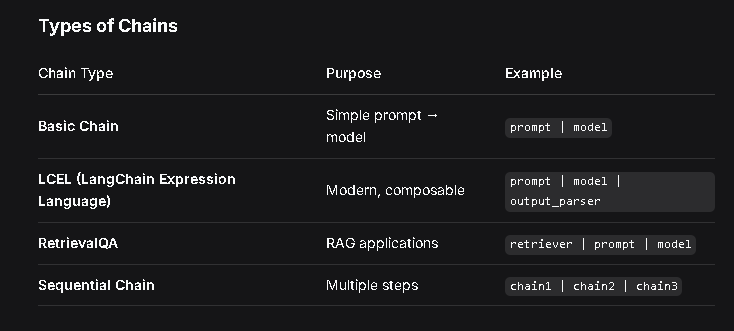

### Code Examples

#### Basic Chain

In [14]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

model = ChatOpenAI(model="gpt-4o-mini")

# Simple chain
template = ChatPromptTemplate.from_messages([
    ("system", "You are a {role}."),
    ("human", "{input}")
])

chain = template | model

response = chain.invoke({
    "role": "poet",
    "input": "Write a haiku about coding in less then 1 line"
})
print(response.content)

Lines of logic flow,  
Digital dreams take their form—  
Silicon whispers.


#### Sequential Chain


In [16]:
from langchain_core.output_parsers import StrOutputParser

# Step 1: Translate
translate_template = ChatPromptTemplate.from_messages([
    ("system", "Translate to {language}."),
    ("human", "{text}")
])
translate_chain = translate_template | model | StrOutputParser()

# Step 2: Summarize
summarize_template = ChatPromptTemplate.from_messages([
    ("system", "Summarize in less then 1 line."),
    ("human", "{text}")
])
summarize_chain = summarize_template | model | StrOutputParser()

# Step 3: Chain them together
full_chain = translate_chain | summarize_chain

result = full_chain.invoke({
    "text": "The quick brown fox jumps over the lazy dog.",
    "language": "Hindi"
})
print(result)

गिलहरी कुत्ते के ऊपर कूदती है।


#### Chain with Multiple Outputs

In [17]:
from langchain_core.runnables import RunnableParallel
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_openai import ChatOpenAI

model = ChatOpenAI(
    model="gpt-3.5-turbo",  # or "gpt-4"
    temperature=0.7
)

template = ChatPromptTemplate.from_messages([
    ("system", "You are a {role} expert with 10+ years of experience."),
    ("human", "{input}")
])

example_template = ChatPromptTemplate.from_messages([
    ("system", "You are a {role} expert. Provide 2 clear, practical examples."),
    ("human", "Show me 3 examples of {input} in real-world {role} code.")
])


parallel_chain = RunnableParallel({
    "explanation": template | model | StrOutputParser(),
    "examples": example_template | model | StrOutputParser(),
})


result = parallel_chain.invoke({
    "role": "Python developer",
    "input": "Explain decorators"
})


print(result["explanation"])
print(result["examples"])

Decorators in Python are a powerful and flexible way to modify or extend the behavior of functions or methods without changing their code. Decorators are functions themselves that take another function as an argument and return a new function that usually extends the functionality of the original function in some way.

Here's a basic example to illustrate how decorators work:

```python
def my_decorator(func):
    def wrapper():
        print("Something is happening before the function is called.")
        func()
        print("Something is happening after the function is called.")
    return wrapper

@my_decorator
def say_hello():
    print("Hello!")

say_hello()
```

In this example, `my_decorator` is a decorator function that takes `say_hello` as an argument. When `say_hello` is called, it actually calls the `wrapper` function returned by the decorator, which adds some functionality before and after the original `say_hello` function is called.

Decorators are commonly used for tasks

#### Chain with Custom Functions

In [20]:
from langchain_core.runnables import RunnableLambda
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_openai import ChatOpenAI

# 1. Setup model
model = ChatOpenAI(
    model="gpt-3.5-turbo",
    temperature=0.7
)

# 2. Define the prompt template (expects 'role' and 'input')
template = ChatPromptTemplate.from_messages([
    ("system", "You are a {role}."),
    ("human", "{input}")
])

# 3. Define transformation functions
def clean_and_keep_structure(data: dict) -> dict:
    """
    CRITICAL FIX: This function now returns a DICTIONARY,
    not a string. It preserves the 'role' and cleans the 'input'.
    """
    return {
        "role": data["role"],  # Pass role through unchanged
        "input": data["input"].strip().lower()  # Clean only the input text
    }

def format_output(text: str) -> str:
    """Format the final output with markdown bold."""
    return f"**{text}**"

# 4. Create RunnableLambda wrappers
clean_chain = RunnableLambda(clean_and_keep_structure)
format_chain = RunnableLambda(format_output)

# 5. Build the full chain
# The data flow is now:
# Dict -> clean_chain (returns Dict) -> template (accepts Dict) -> model -> StrOutputParser() -> format_chain
full_chain = (
    clean_chain 
    | template 
    | model 
    | StrOutputParser() 
    | format_chain
)

# 6. Invoke the chain
result = full_chain.invoke({
    "role": "teacher",
    "input": "  EXPLAIN PYTHON IN LESS THAN 1 LINE  "
})

print(result)

**Python is a high-level, interpreted programming language known for its simplicity and readability.**


## 4. MEMORY

- LLM APIs are stateless - each call is independent. The model doesn't remember previous conversations.

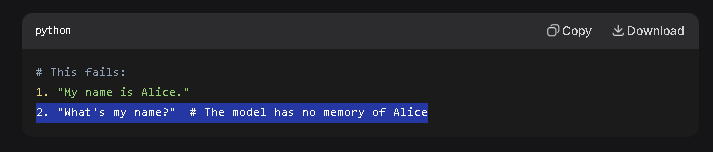

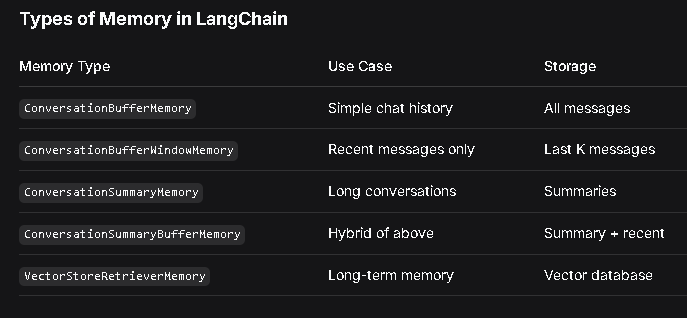


1. **ConversationBufferMemory** - Saves EVERY message in the conversation, All context preserved and most accurate but it gets very large with long conversations and Expensive (more tokens sent to LLM). we can use it for Short conversations, small token budgets

2. **ConversationBufferWindowMemory** - Only keeps the last K messages (conversation turns). It has Fixed memory size and Cheaper (fewer tokens) but It loses older context and User might need to repeat information. We can use it for Long conversations where only recent context matters, cost optimization


3. **ConversationSummaryMemory** - Summarizes older messages instead of keeping everything. It handles extremely long conversations. Only summary is stored (not all messages) but Uses LLM to summarize (costs tokens), Summary may lose details and No access to original messages. we can use it where Very long conversations, when you need to remember the gist, not every detail

4. **ConversationSummaryBufferMemory** - Its a Hybrid approach: keeps recent messages AND a summary of older ones. Its a Best balance of cost and context. Keeps recent details & Summarizes old info but It Uses LLM for summarization & More complex to configure. we can use it where Large conversations where you need both recent details and overall context

5. **VectorStoreRetrieverMemory** - Uses a vector database to store messages and retrieve relevant ones. It Can be persistent (if configured with persist_directory). Long-term memory possible, It Only retrieves relevant memories (not all) and it Scales well with many memories but it Requires vector DB setup, Uses embedding for storage (costs tokens) and it has More complex setup. We can use it where Applications needing long-term user memory, recommendation systems, multi-session conversations

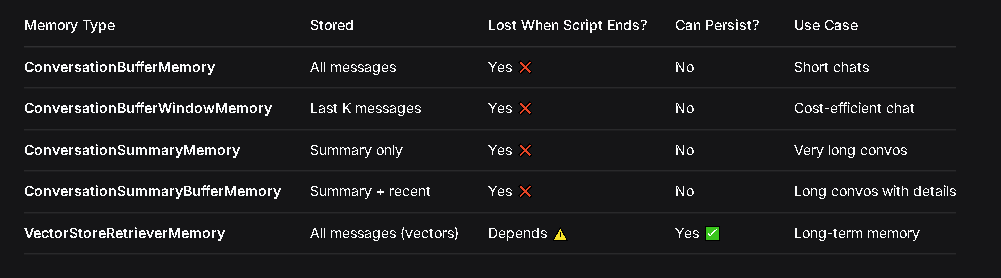

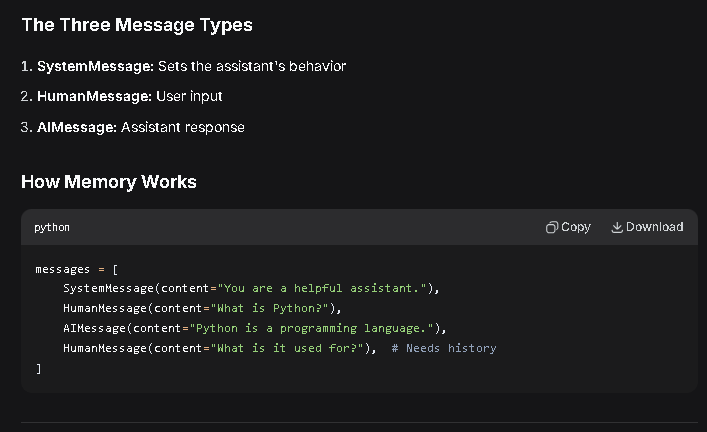

### Manual Memory with Session State

In [22]:
from langchain_core.messages import HumanMessage, AIMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

# Initialize history
chat_history = []

# Template with placeholder
template = ChatPromptTemplate.from_messages([
    ("system", "You are a helpful assistant."),
    MessagesPlaceholder(variable_name="chat_history"),
    ("human", "{user_input}")
])

chain = template | model

while True:
    user_input = input("You: ")
    if user_input.lower() == "exit":
        break
    
    response = chain.invoke({
        "user_input": user_input,
        "chat_history": chat_history
    })
    
    chat_history.append(HumanMessage(content=user_input))
    chat_history.append(AIMessage(content=response.content))
    
    print(f"AI: {response.content}")

AI: Hello! How can I assist you today?
AI: Hello Prashant! It's nice to meet you. How can I help you today?


### ConversationBufferMemory

In [27]:
!pip install langchain_classic

In [28]:
# Replace the old imports with these
from langchain_classic.memory import ConversationBufferMemory
from langchain_classic.chains import ConversationChain
from langchain_openai import ChatOpenAI

# The rest of your code stays exactly the same
memory = ConversationBufferMemory()
conversation = ConversationChain(
    llm=ChatOpenAI(model="gpt-4o-mini"),
    memory=memory
)

response = conversation.predict(input="Hi, I'm John.")
print(response)

response = conversation.predict(input="What's my name?")
print(response)

C:\Users\iampr\AppData\Local\Temp\ipykernel_12588\56020123.py:7: LangChainDeprecationWarning: The class `ConversationBufferMemory` was deprecated in LangChain 0.3.1 and will be removed in 2.0.0. Use `langchain.agents.create_agent` instead. For agents that need to remember prior interactions, use `create_agent` with checkpointing or the `Store` API. See https://docs.langchain.com/oss/python/langchain/short-term-memory and https://docs.langchain.com/oss/python/langchain/long-term-memory
  memory = ConversationBufferMemory()
C:\Users\iampr\AppData\Local\Temp\ipykernel_12588\56020123.py:8: LangChainDeprecationWarning: The class `ConversationChain` was deprecated in LangChain 0.2.7 and will be removed in 2.0.0. Use `langchain.agents.create_agent` instead. Build a conversational agent with `langchain.agents.create_agent` and persist message history via a LangGraph checkpointer.
  conversation = ConversationChain(


Hello, John! It's great to meet you! I'm here to chat and help with anything you might need. How's your day going so far?
Your name is John! It's nice to meet you. Do you want to tell me a bit about yourself, or is there something specific you'd like to discuss today?


## 5. STRUCTURED OUTPUT

- **Problem: Unstructured Output**
    - LLMs return unstructured text, which is hard to use programmatically.

- **Solution: Structured Output**
    - Define a schema, and the LLM returns data in that exact format.


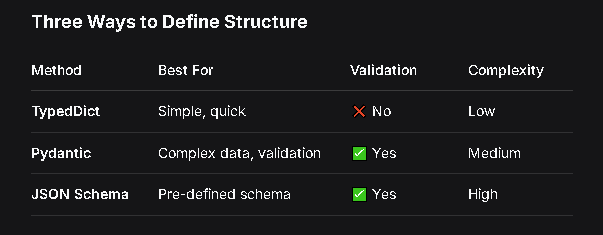


**How it works?**
- You define the structure
- Call .with_structured_output()
- LangChain crafts a prompt and parses the response
- You get a validated object back

### Key Concept: Annotated

In [30]:
from typing import Annotated, List, TypedDict

class Review(TypedDict):
    # Free text with description
    summary: Annotated[
        str,
        "A concise summary of the review"
    ]
    
    # Numeric with range
    score: Annotated[
        float,
        "Score from -1 (very negative) to 1 (very positive)"
    ]
    
    # List with description
    keywords: Annotated[
        List[str],  # List is now imported
        "Key topics mentioned in the review"
    ]

# Example usage
review: Review = {
    "summary": "Great product, works perfectly!",
    "score": 0.9,
    "keywords": ["performance", "reliability", "value"]
}

print(review)

{'summary': 'Great product, works perfectly!', 'score': 0.9, 'keywords': ['performance', 'reliability', 'value']}


## Code Examples

### TypedDict (Quick & Simple)

In [31]:
from typing import TypedDict, Annotated
from langchain_openai import ChatOpenAI

class Review(TypedDict):
    summary: str
    sentiment: str
    
    # Description using Annotated
    score: Annotated[
        float,
        "Score from -1 (negative) to 1 (positive)"
    ]

# Bind and use
model = ChatOpenAI(model="gpt-4o-mini")
structured_model = model.with_structured_output(Review)

result = structured_model.invoke(
    "Great service, friendly staff, excellent experience!"
)

print(result)

{'summary': 'The service was exceptional, with a very friendly staff that greatly enhanced the overall experience.', 'sentiment': 'positive', 'score': 5}


### Pydantic (Best for Most Use Cases)

In [32]:
from pydantic import BaseModel, Field
from typing import List

class SentimentAnalysis(BaseModel):
    """Analyze sentiment of a review."""
    
    sentiment: str = Field(
        description="The overall sentiment: positive, negative, or neutral"
    )
    
    score: float = Field(
        description="Score from -1 (very negative) to 1 (very positive)",
        ge=-1,  # Greater than or equal to -1
        le=1    # Less than or equal to 1
    )
    
    key_phrases: List[str] = Field(
        description="Exact phrases from the review that support the sentiment"
    )
    
    confidence: float = Field(
        description="Confidence score from 0 to 1",
        ge=0,
        le=1
    )

# Use it
structured_model = model.with_structured_output(SentimentAnalysis)

result = structured_model.invoke(
    "The food was amazing but the service was incredibly slow."
)

# Access as object
print(f"Sentiment: {result.sentiment}")
print(f"Score: {result.score}")
print(f"Phrases: {', '.join(result.key_phrases)}")
print(f"Confidence: {result.confidence:.2f}")

Sentiment: mixed
Score: 0.2
Phrases: The food was amazing, the service was incredibly slow
Confidence: 0.85


### Complex Nested Structure

In [34]:
from pydantic import BaseModel, Field
from typing import List
from langchain_openai import ChatOpenAI

# 1. Define the Address model first
class Address(BaseModel):
    street: str
    city: str
    state: str
    country: str

# 2. Define the Person model
class Person(BaseModel):
    name: str
    age: int = Field(ge=0, le=150)
    email: str
    address: Address
    hobbies: List[str]
    is_active: bool

# 3. Create the model
model = ChatOpenAI(model="gpt-3.5-turbo", temperature=0)

# 4. Create structured output
structured_model = model.with_structured_output(Person)

# 5. Invoke with the text
result = structured_model.invoke("""
John Doe, 32, john@email.com, lives at 123 Main St, NYC, USA.
Enjoys hiking, reading, and photography. Currently active.
""")

# 6. Display results
print(f"Name: {result.name}")
print(f"City: {result.address.city}")
print(f"Hobbies: {', '.join(result.hobbies)}")
print(f"Age: {result.age}")
print(f"Email: {result.email}")
print(f"Active: {result.is_active}")

d:\Agentic AI\GenAI using Langchain\venv\lib\site-packages\langchain_openai\chat_models\base.py:2393: UserWarning: Cannot use method='json_schema' with model gpt-3.5-turbo since it doesn't support OpenAI's Structured Output API. You can see supported models here: https://platform.openai.com/docs/guides/structured-outputs#supported-models. To fix this warning, set `method='function_calling'. Overriding to method='function_calling'.
  warnings.warn(


Name: John Doe
City: NYC
Hobbies: hiking, reading, photography
Age: 32
Email: john@email.com
Active: True


In [36]:
# from pydantic import BaseModel, Field
# from typing import List, Optional
# from langchain_openai import ChatOpenAI
# from langchain_community.document_loaders import PyPDFLoader
# from pathlib import Path
# import pandas as pd

# # Define your extraction model
# class DocumentRecord(BaseModel):
#     title: str = Field(description="Document title")
#     summary: str = Field(description="2-3 sentence summary")
#     doc_type: str = Field(description="Document type: report, article, manual, etc.")
#     topic_category: str = Field(description="Primary subject domain")
#     sentiment: str = Field(description="Overall tone: positive, neutral, or negative")

# # Setup
# model = ChatOpenAI(model="gpt-4o-mini", temperature=0)
# structured_model = model.with_structured_output(DocumentRecord)

# # Process all PDFs in a directory
# pdf_dir = Path("./pdf_documents")
# results = []

# for pdf_path in pdf_dir.glob("*.pdf"):
#     print(f"Processing: {pdf_path.name}")
    
#     # Load PDF
#     loader = PyPDFLoader(str(pdf_path))
#     pages = loader.load()
#     full_text = "\n\n".join([p.page_content for p in pages])
    
#     try:
#         # Extract structured data
#         record = structured_model.invoke(f"""
#         Extract structured information from this document:

#         {full_text[:8000]}  # Limit to avoid token limits
#         """)
        
#         # Store results
#         results.append({
#             "filename": pdf_path.name,
#             "title": record.title,
#             "summary": record.summary,
#             "doc_type": record.doc_type,
#             "topic": record.topic_category,
#             "sentiment": record.sentiment
#         })
#     except Exception as e:
#         print(f"  Error processing {pdf_path.name}: {e}")

# # Save to CSV
# df = pd.DataFrame(results)
# df.to_csv("extracted_data.csv", index=False)
# print(f"Extracted data from {len(results)} PDFs")

## RAG (Retrieval Augmented Generation)

- RAG combines retrieval (finding relevant documents) with generation (answering based on them). It solves the problem of LLMs only knowing what they were trained on.

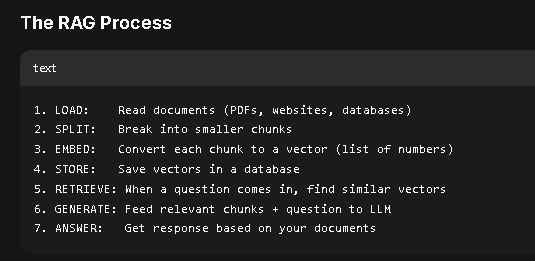

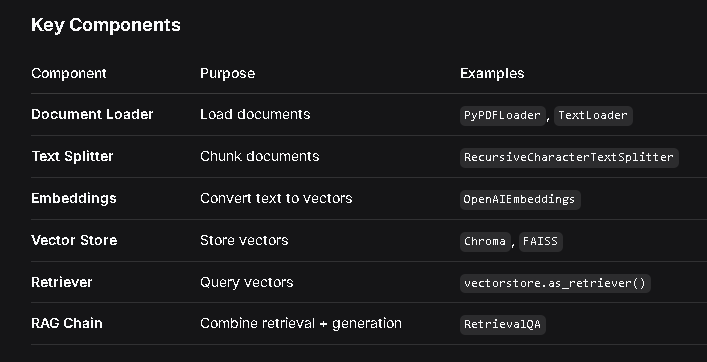

### Basic PDF RAG

In [37]:
# from langchain_openai import ChatOpenAI, OpenAIEmbeddings
# from langchain_community.document_loaders import PyPDFLoader
# from langchain.text_splitter import RecursiveCharacterTextSplitter
# from langchain_community.vectorstores import Chroma
# from langchain.chains import RetrievalQA
# import tempfile
# import os

# # 1. Load
# loader = PyPDFLoader("document.pdf")
# documents = loader.load()

# # 2. Split
# splitter = RecursiveCharacterTextSplitter(
#     chunk_size=1000,
#     chunk_overlap=200,
# )
# chunks = splitter.split_documents(documents)

# # 3. Embed & Store
# embeddings = OpenAIEmbeddings()
# vectorstore = Chroma.from_documents(chunks, embeddings)

# # 4. Create retriever
# retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

# # 5. Create chain
# model = ChatOpenAI(model="gpt-4o-mini")
# qa_chain = RetrievalQA.from_chain_type(
#     llm=model,
#     chain_type="stuff",
#     retriever=retriever,
#     return_source_documents=True
# )

# # 6. Ask questions
# result = qa_chain.invoke({"query": "What is the main topic?"})
# print(f"Answer: {result['result']}")
# print(f"Sources: {len(result['source_documents'])} chunks used")